# Predicting Apartment Rental Prices: A Feature Impact Analysis

**Author:** Kyle Ho  

**GitHub Repository:**  https://github.com/Kyleho1/DSCI_235_Project

**Dataset:** https://archive.ics.uci.edu/dataset/555/apartment+for+rent+classified

---
#Introduction

**Motivation & Goals:** In this project, I analyze a dataset of rental housing listings to better understand the factors that influence rental prices. Finding a apartment is very signficant and often the most financially burdening expense many people face. Despite its importance, finding the right apartment and understanding pricing still remains unessecarily confusing. This project takes a data-driven approach to demystifying that process.

Using approximately 100,000 apartment rental listings, the notebook will attempt to:


1.   Explores the structure and quality of the data
2.   Preprocesses and engineer features for modeling
3. Builds and compare Linear Regression and Random Forest models
4. Quantifies which features most strongly drive rental prices
5. Investigates feature interactions (example: does square footage matter more in expensive states?)
6. Identifies noise features that don't meaningfully affect price.



### Main Questions
1. Which features have the greatest impact on rental prices?
2. Are there meaningful interactions between features?
3. Which features appear to be distractors that don't drive costs?



#Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [2]:
pip install ucimlrepo


In [3]:
from ucimlrepo import fetch_ucirepo


#Data Exploration
Goal: Assess data quality and patterns. Check missing values, examine price distributions, explore iniital relationship between square footage and price. This might help us decide what columns we want or give us more detailed information on teh dataset.

In [4]:
#load data
apartment_for_rent_classified = fetch_ucirepo(id=555)
X = apartment_for_rent_classified.data.features
y = apartment_for_rent_classified.data.targets
df = pd.concat([X, y], axis=1)
print(df.shape)


/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0,5,6,12,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


(99826, 21)


In [5]:
missing = (df.isnull().sum() / len(df) * 100).round(2)
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing.head(10))
else:
    print("No missing values found")

address         92.04
pets_allowed    60.74
amenities       16.11
cityname         0.31
state            0.31
bedrooms         0.13
bathrooms        0.07
longitude        0.03
latitude         0.03
price            0.01
dtype: float64


In [6]:
print("Price stats")
print(f"Min: ${df['price'].min():,.0f}")
print(f"Median: ${df['price'].median():,.0f}")
print(f"Mean: ${df['price'].mean():,.0f}")
print(f"Max: ${df['price'].max():,.0f}")
print(f"Std: ${df['price'].std():,.0f}")

Price stats
Min: $100
Median: $1,350
Mean: $1,527
Max: $52,500
Std: $904


In [7]:
sample_amenities = df['amenities'].dropna().head(5)
sample_amenities

,amenities
21,"Fireplace,Gym,Parking,Pool,Storage,Wood Floors"
22,"Gated,Pool"
23,"Dishwasher,Parking,Pool"
24,"Dishwasher,Parking,Pool"
25,"Gym,Pool"


In [8]:
print(f"Unique cities: {df['cityname'].nunique():,}")

Unique cities: 2,984


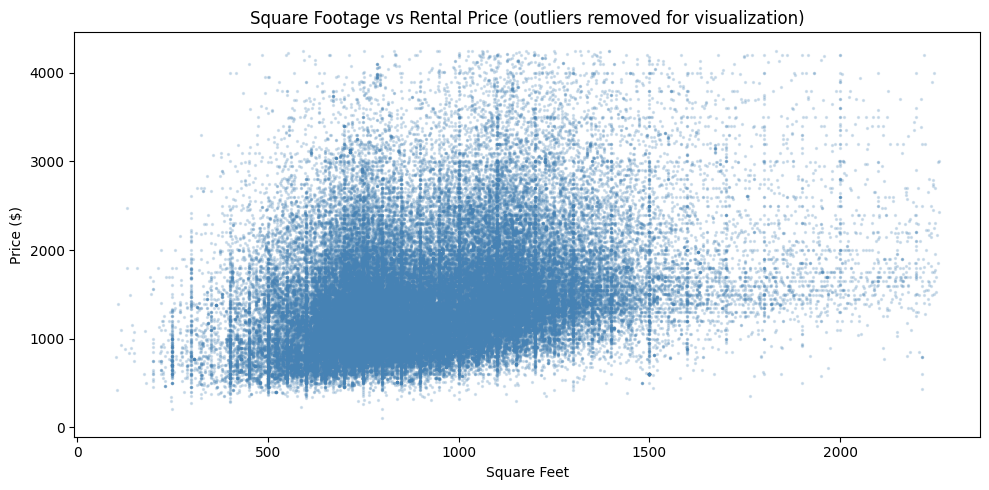

In [9]:
df_temp = df[['square_feet', 'price']].copy()
df_temp['square_feet'] = pd.to_numeric(df_temp['square_feet'], errors='coerce')
df_temp = df_temp.dropna()
#cap outliers for better visualization
sqft_cap = df_temp['square_feet'].quantile(0.99)
price_cap = df_temp['price'].quantile(0.99)
df_temp = df_temp[(df_temp['square_feet'] <= sqft_cap) & (df_temp['price'] <= price_cap)]

plt.figure(figsize=(10, 5))
plt.scatter(df_temp['square_feet'], df_temp['price'], alpha=0.2, s=2, color='steelblue')
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.title('Square Footage vs Rental Price (outliers removed for visualization)')
plt.tight_layout()
plt.show()

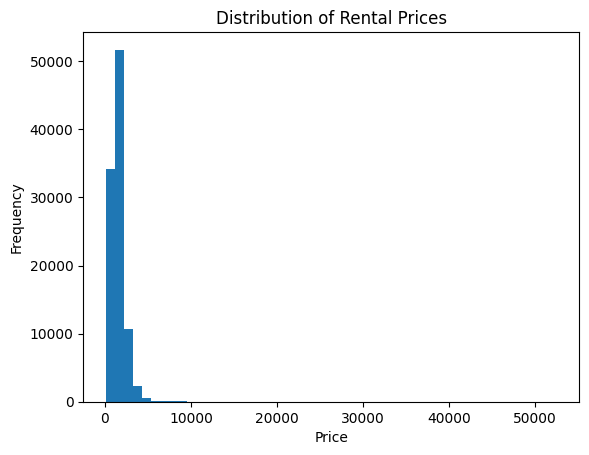

In [24]:
plt.figure()
df['price'].dropna().plot(kind='hist', bins=50)
plt.title('Distribution of Rental Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [10]:
print("Top 10 States by Listing Count")
top_states = df['state'].value_counts().head(10)
print(top_states)

Top 10 States by Listing Count
state
TX    11279
CA    10341
VA     8305
NC     6308
CO     6295
FL     5788
MD     5309
MA     5041
OH     4911
GA     4790
Name: count, dtype: int64


I began by exploring how rental prices are distributed and how they relate to a few key features in the dataset. Prices are not evenly spread out, most listings fall on the lower end, with a smaller number of much higher-priced properties creating a noticeable right skew. Looking at square footage against price, there is a general upward trend, but it’s far from tight, suggesting that size alone doesn’t explain pricing. That spread points to other factors, especially location, playing a meaningful role. Based on these patterns, it made sense to move toward models that can handle more complex, non-linear relationships rather than relying only on simple linear assumptions.

#Data Cleaning
Goal: Before data modeling, we need to clean the raw data by dropping unusuable text columns, removing the outliers, fixing numeric columns that were stored as strings. We also need to fill in missing values with either unkown for text columns and the median of the column. Reduce the cities because there would be an excessive number of variables if we used all unique cities. Simplify complex columns. One hot encode categroial features.

In [11]:
#not useful columns and ones that are difficult to work with
useless_cols = ['title', 'body', 'address', 'source', 'time',
                'currency', 'fee', 'price_display', 'price_type', 'has_photo']
df_clean = df.drop(columns=[c for c in useless_cols if c in df.columns])

#get rid of outliers
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')
df_clean = df_clean.dropna(subset=['price'])
low = df_clean['price'].quantile(0.01)
high = df_clean['price'].quantile(0.99)
df_clean = df_clean[(df_clean['price'] >= low) & (df_clean['price'] <= high)]

numeric_fix = ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude']
for col in numeric_fix:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [12]:
#replace the na in numeric to the median of the col and "Unkown" for categorial

for col in numeric_fix:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

cat_cols = ['category', 'cityname', 'state', 'pets_allowed']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

df_clean['amenities_count'] = df_clean['amenities'].fillna('').str.count(',') + (df_clean['amenities'] != '').astype(int)
df_clean = df_clean.drop(columns=['amenities'])

#weird value
df_clean.loc[df_clean['state'] == 'RentDigs.com', 'state'] = 'Unknown'


#skewed prices, create a log price
df_clean['log_price'] = np.log1p(df_clean['price'])

print(f"model shape: {df_clean.shape}")


model shape: (97884, 12)


In [13]:
# Only keep top 30 cities (otherwise too many dummy columns)
top_n = 50 # with all the unqiue cities it came out to an 2892 to big
top_cities = df_clean['cityname'].value_counts().nlargest(top_n).index

df_clean['cityname'] = df_clean['cityname'].where(
    df_clean['cityname'].isin(top_cities),
    'Other'
)

#Simple pets consolidation easier than before
pets_map = {
    'Cats,Dogs,None': 'All',
    'Cats,Dogs': 'All',
    'Dogs': 'Dogs_only',
    'Cats': 'Cats_only',
    'None': 'None'
}
df_clean['pets_allowed'] = df_clean['pets_allowed'].replace(pets_map)


df_model = pd.get_dummies(df_clean, columns=['category', 'cityname', 'state', 'pets_allowed'],
                          drop_first=True)

#keep only the numeric columns
df_model = df_model.select_dtypes(include='number')

print(f"Model shape: {df_model.shape}")

Model shape: (97884, 8)


In [14]:
df_model.head(1)

,bathrooms,bedrooms,price,square_feet,latitude,longitude,amenities_count,log_price
0,1.0,1.0,2195.0,542.0,33.852,-118.3759,1,7.694393


#Train Models


1.   Linear Regression
2.   Random Forest



In [15]:
X = df_model.drop(columns=['price', 'log_price'])
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_lr = np.clip(y_pred_lr, 4.6, 11.5)


# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluation function for dollars
def rmse_dollars(y_true_log, y_pred_log):
    # Clip predictions to reasonable log price range log(100) ≈ 4.6, log(100,000) ≈ 11.5
    y_pred_log = np.clip(y_pred_log, 4, 15)

    true_dollars = np.expm1(y_true_log)
    pred_dollars = np.expm1(y_pred_log)

    #It will break without this because of inf values
    if np.isinf(pred_dollars).any() or np.isnan(pred_dollars).any():
        return 0.0

    return np.sqrt(mean_squared_error(true_dollars, pred_dollars))

print(f"Linear Regression Test RMSE: ${rmse_dollars(y_test, y_pred_lr):,.0f}")
print(f"Random Forest Test RMSE: ${rmse_dollars(y_test, y_pred_rf):,.0f}")

Linear Regression Test RMSE: $1,522
Random Forest Test RMSE: $247


The random forest has 6x less error. This dramatic difference tells us that rental pricing follows complex, non-linear patterns that a simple linear model cannot capture. The model predicts log_price, and when converting back to dollars with np.expm1(), it can explode into millions of dollars with moderatly extreme predictions so we added clopping. Clipping forces the predicitons to stay within a realisitic range

#Analysis


##Question 1: Which features have the greatest impact on rental prices?


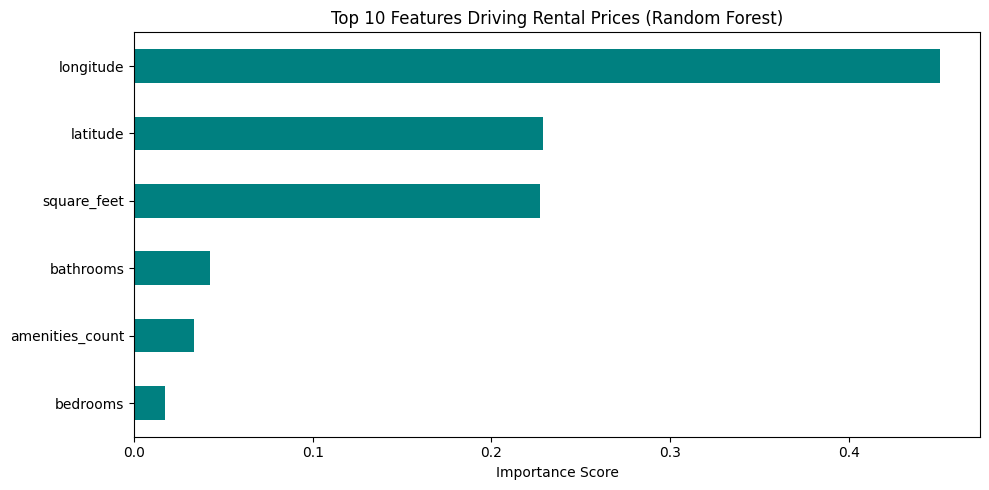


Top 5 most important features:
  1. longitude: 0.4509
  2. latitude: 0.2287
  3. square_feet: 0.2274
  4. bathrooms: 0.0424
  5. amenities_count: 0.0334


In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_features.sort_values().plot.barh(color='teal')
plt.title('Top 10 Features Driving Rental Prices (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for i, (feat, imp) in enumerate(top_features.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

In [17]:
lr_coefs = pd.Series(lr.coef_, index=X.columns)
top_lr = lr_coefs.abs().sort_values(ascending=False).head(5)
print("\nTop 5 by Linear Regression (absolute coefficient):")
for feat, coef in top_lr.items():
    print(f"  {feat}: {coef:.4f}")


Top 5 by Linear Regression (absolute coefficient):
  bathrooms: 0.1222
  bedrooms: 0.0680
  latitude: 0.0131
  amenities_count: 0.0052
  longitude: 0.0028


The strongest predicitng features from the Random Forest are longitude, latitude, square feet, bathrooms, amentitiy count. The strongest features from linear regression was bathrooms, bedrooms, latitude, amenity count, longitude.

The Random Forest model revealed that location which is captured by longitude (0.4509) and latitude (0.2287) is overwhelmingly the dominant factor, accounting for nearly 70% of total importance. Linear Regression told a completely different story, with bathrooms being the largest coefficient and the location features closer to the bottom.

This disagreement between models reveals something important but not unexpected. Linear Regression assumes each feature adds value at a constant rate, but Random Forest can capture diminishing returns and non-linear patterns. For example, the first extra bedroom adds significant value while the fifth adds very little. Location and Bathroom show up in both top features that suggest that those features have a relatively linear relationship with price.

Overall the disagreement in models shows that rental pricing is complex and non linear. In short, location is the single most important factor.

##Question 2: Are there meaningful interactions between features?


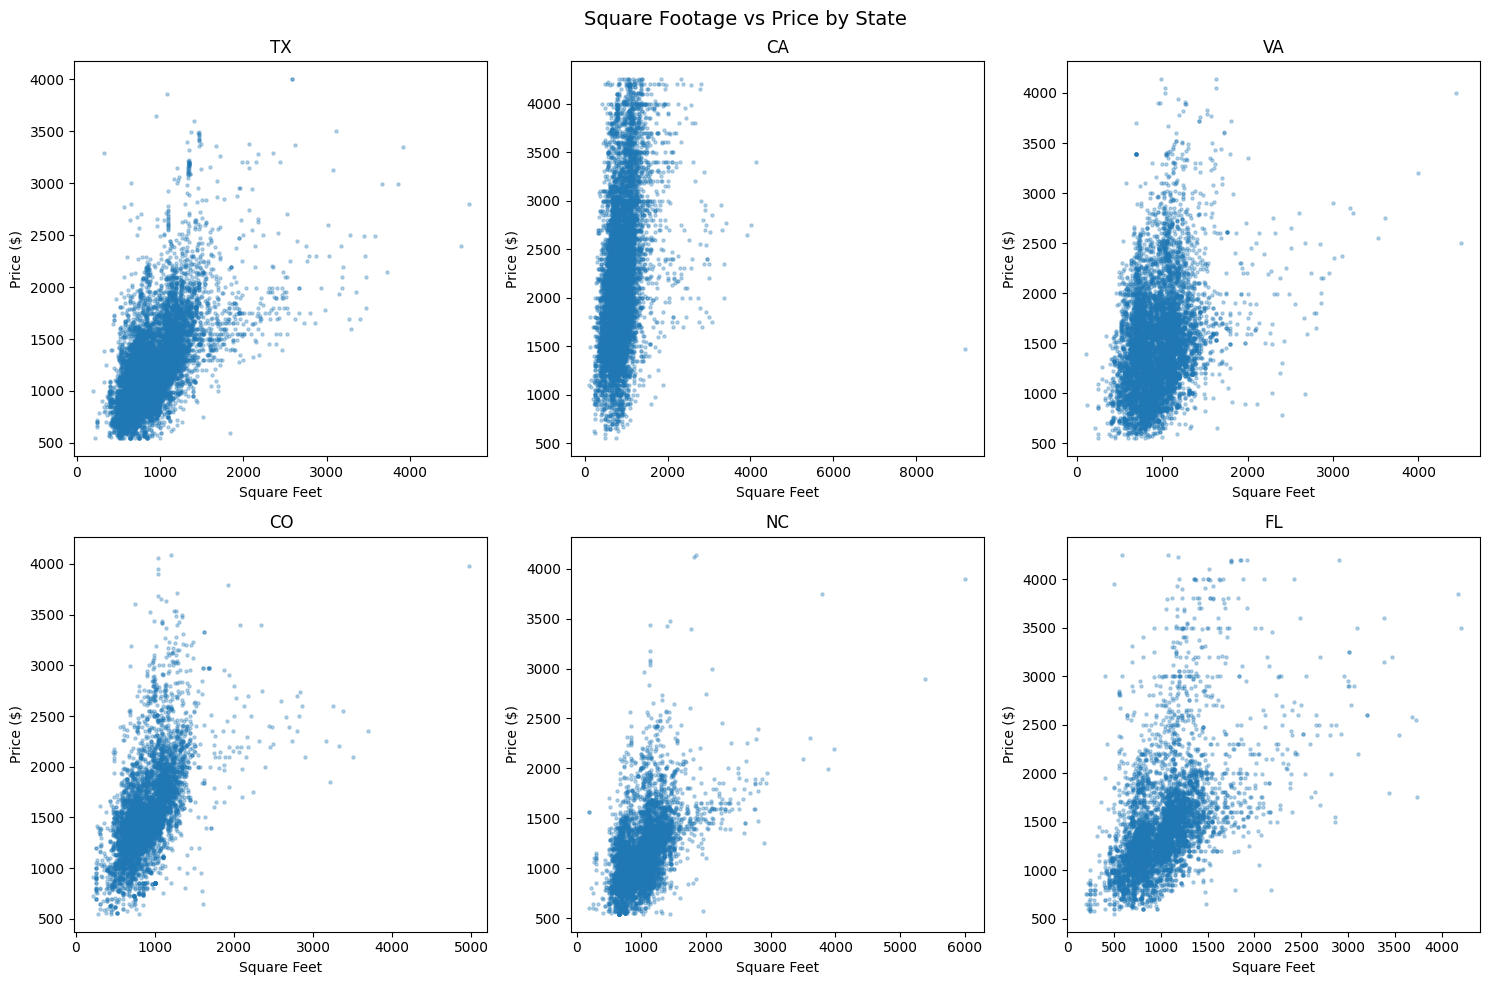

In [18]:
top_states = df_clean['state'].value_counts().head(5).index.tolist()
# Scatter plots by state
top_states = df_clean['state'].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, state in enumerate(top_states):
    state_data = df_clean[df_clean['state'] == state][['square_feet', 'price']].dropna()

    # Basic scatter plot
    axes[i].scatter(state_data['square_feet'], state_data['price'], alpha=0.3, s=5)
    axes[i].set_title(state)
    axes[i].set_xlabel('Square Feet')
    axes[i].set_ylabel('Price ($)')

plt.suptitle('Square Footage vs Price by State', fontsize=14)
plt.tight_layout()
plt.show()

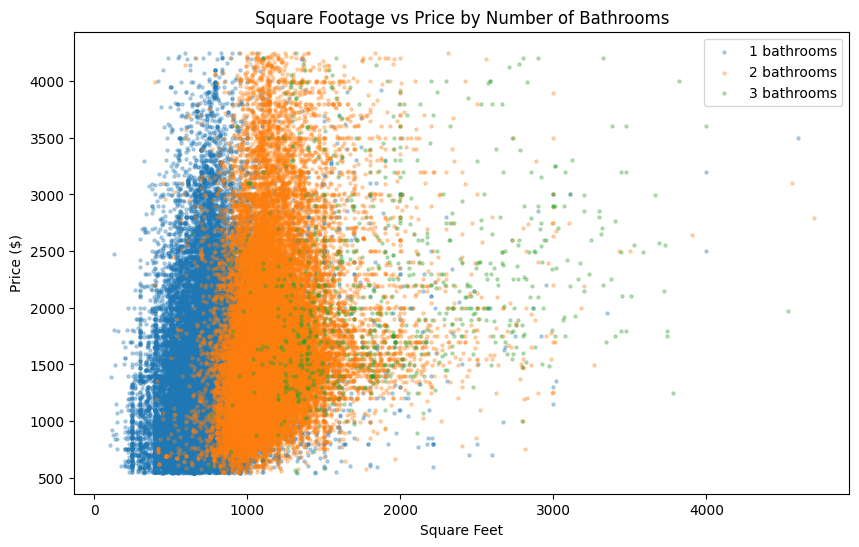

In [19]:
#Square footage and bathroom relationship
plt.figure(figsize=(10, 6))
for bathrooms in [1, 2, 3]:
    subset = df_clean[df_clean['bathrooms'] == bathrooms]
    subset = subset[(subset['square_feet'] < 8000)]
    plt.scatter(subset['square_feet'], subset['price'],
                alpha=0.3, s=5, label=f'{bathrooms} bathrooms')

plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.title('Square Footage vs Price by Number of Bathrooms')
plt.legend()
plt.show()

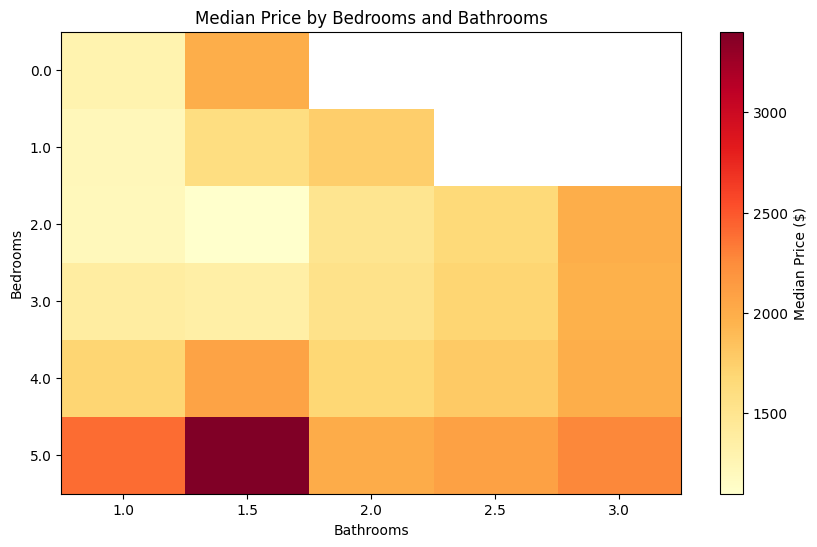

In [20]:
pivot = df_clean.pivot_table(values='price',
                              index='bedrooms',
                              columns='bathrooms',
                              aggfunc='median')

pivot = pivot.loc[:5, :3]

plt.figure(figsize=(10, 6))
plt.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Median Price ($)')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('Bathrooms')
plt.ylabel('Bedrooms')
plt.title('Median Price by Bedrooms and Bathrooms')
plt.show()

To see how features interacted with each other meaninguflly I created three visualizations: square footage vs. price segmented by state, square footage vs. price segmented by number of bathrooms, and a heatmap of median price by bedroom and bathroom combinations. I chose these combinations based on what I think could be meaningful from what I know.

The first figure (square-footage vs price by state) shows that square footage has a positive correlation with these 6 states. The steepness of the slope indicates how valuable square footage is in that state. The steeper it is the more it drives the price.

The second figure (square footage by price by number of bathrooms) does not show any interaction between, the number of bathrooms and price. No matter the bathroom cost there are low and high prices. The square footage obviosuly go up with more bathrooms.

The third figure is a heatmap showing the meidan price for each combination of bedrooms and bathrooms. The price steadily increases as both bathrooms and bedrooms increase. It also looks like bathrooms is more important because the price steadily increases steadily on the x axis no matter the bedrooms. And the bedrooms don't drive the price up consistently


##Question 3:Which features appear to be distractors that don't drive costs?

In [21]:
low_importance_threshold = importances.quantile(0.2)
distractors = importances[importances <= low_importance_threshold]

print(f"Features with importance below {low_importance_threshold:.4f} (bottom 20%):")
for feat, imp in distractors.sort_values().head(15).items():
    print(f"  {feat}: {imp:.4f}")

useful_features = [c for c in X.columns if c not in distractors.index]
X_reduced = X[useful_features]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

rf_reduced = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reduced.fit(Xr_train, yr_train)
yr_pred = rf_reduced.predict(Xr_test)

rmse_full = rmse_dollars(y_test, y_pred_rf)
rmse_reduced = rmse_dollars(yr_test, yr_pred)

print(f"RMSE with ALL features: ${rmse_full:,.0f}")
print(f"RMSE without distractors: ${rmse_reduced:,.0f}")
print(f"Difference: ${rmse_reduced - rmse_full:+,.0f}")

Features with importance below 0.0334 (bottom 20%):
  bedrooms: 0.0172
  amenities_count: 0.0334
RMSE with ALL features: $247
RMSE without distractors: $257
Difference: $+10


The two features that I determiend were distractors are bedrooms and amenities_count. Removing them made the RMSE go up by only 10 meaning that they added little to no predicitve value. This means that the amount of bedrooms and amentities are weak signals and not what drive costs. A difference of 10 is small considering that rental prices are often in the thousands.

#Conclusion
The final takeaway for renters is to prioritize location and square footage. Location alone (captured by latitude and longitude) accounted for nearly 70% of predictive importance in our models, confirming that where you live is the dominant factor in what you'll pay.  Bedrooms and amentities were shown to be weaker signals of driving housing prices.

The large performance gap between Random Forest and Linear Regression models tells us that rental pricing follows complex, non-linear patterns that simple additive models cannot capture.

A limitation of this analysis is that location is modeled using only latitude and longitude. While these features can capture geographic position, they do not fully reflect more nuanced factors such as neighborhood quality, access to amenities, or overall desirability, which can significantly influence rental prices. This is the problem when modeling the real world.

#Teamwork

Solo project so I did everything